In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv(r'C:\Users\hp\Desktop\Final_Project\Dataset\retail_store_inventory.csv')

print("=== 1. Dataset Shape ===")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}\n")

print("=== 2. Missing Values ===")
print(df.isnull().sum(), "\n")

print("=== 3. Duplicate Rows ===")
print(f"Number of duplicate rows: {df.duplicated().sum()}\n")

print("=== 4. Numerical Summary Statistics ===")
display(df.describe().T)

print("\n=== 5. Unique Values in Categorical Columns ===")
categorical_cols = ['Category', 'Region', 'Weather Condition', 'Seasonality', 'Holiday/Promotion']
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

=== 1. Dataset Shape ===
Total Rows: 73100, Total Columns: 15

=== 2. Missing Values ===
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64 

=== 3. Duplicate Rows ===
Number of duplicate rows: 0

=== 4. Numerical Summary Statistics ===


,count,mean,std,min,25%,50%,75%,max
Inventory Level,73100.0,274.469877,129.949514,50.00,162.00,273.000,387.0000,500.00
Units Sold,73100.0,136.464870,108.919406,0.00,49.00,107.000,203.0000,499.00
Units Ordered,73100.0,110.004473,52.277448,20.00,65.00,110.000,155.0000,200.00
Demand Forecast,73100.0,141.494720,109.254076,-9.99,53.67,113.015,208.0525,518.55
Price,73100.0,55.135108,26.021945,10.00,32.65,55.050,77.8600,100.00
Discount,73100.0,10.009508,7.083746,0.00,5.00,10.000,15.0000,20.00
Holiday/Promotion,73100.0,0.497305,0.499996,0.00,0.00,0.000,1.0000,1.00
Competitor Pricing,73100.0,55.146077,26.191408,5.03,32.68,55.010,77.8200,104.94



=== 5. Unique Values in Categorical Columns ===
Category: <ArrowStringArray>
['Groceries', 'Toys', 'Electronics', 'Furniture', 'Clothing']
Length: 5, dtype: str
Region: <ArrowStringArray>
['North', 'South', 'West', 'East']
Length: 4, dtype: str
Weather Condition: <ArrowStringArray>
['Rainy', 'Sunny', 'Cloudy', 'Snowy']
Length: 4, dtype: str
Seasonality: <ArrowStringArray>
['Autumn', 'Summer', 'Winter', 'Spring']
Length: 4, dtype: str
Holiday/Promotion: [0 1]


C:\Users\hp\AppData\Local\Temp\ipykernel_23056\2289226171.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Units Sold', data=category_sales, ax=axes[0, 1], palette='Set2')
C:\Users\hp\AppData\Local\Temp\ipykernel_23056\2289226171.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Holiday/Promotion', y='Units Sold', data=df, ax=axes[1, 1], palette='muted')
C:\Users\hp\AppData\Local\Temp\ipykernel_23056\2289226171.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(['Normal Day (0)', 'Holiday/Promotion (1)'])


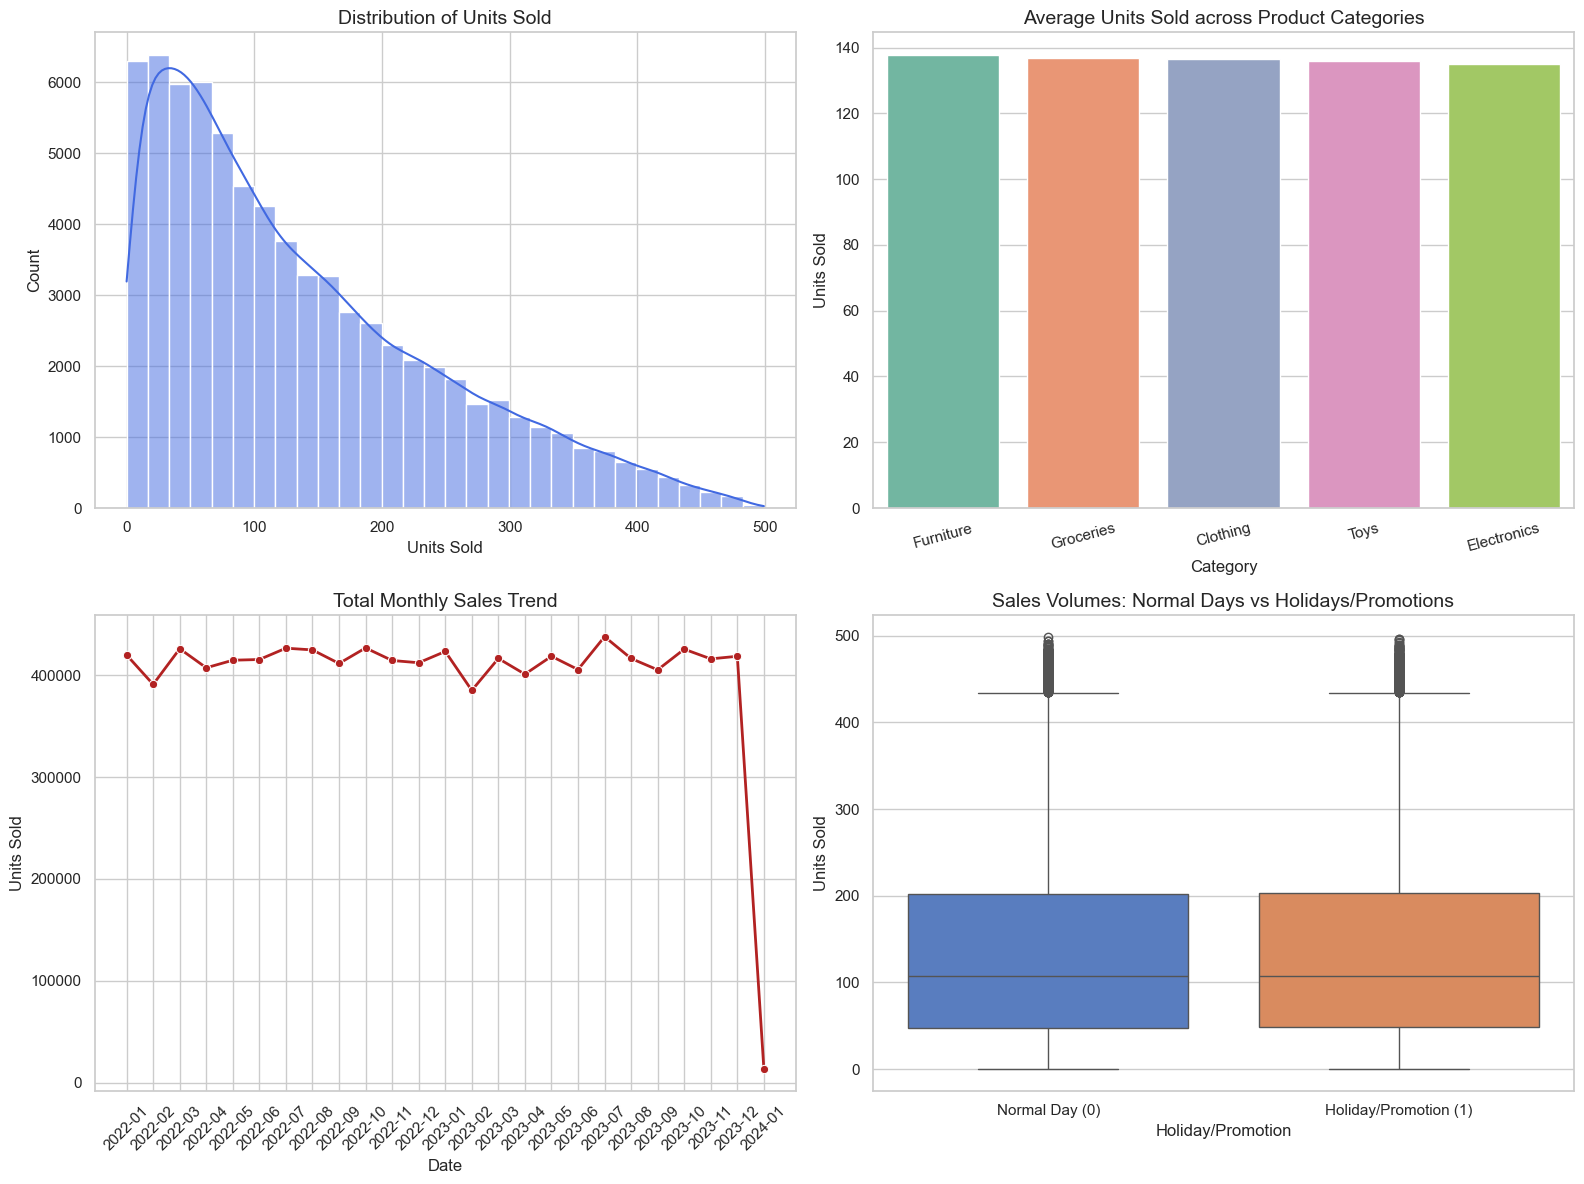

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure date is in datetime format for proper trend visualization
df['Date'] = pd.to_datetime(df['Date'])

# Set up matplotlib style and grid
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of Target Column (Units Sold)
sns.histplot(df['Units Sold'], kde=True, ax=axes[0, 0], color='royalblue', bins=30)
axes[0, 0].set_title('Distribution of Units Sold', fontsize=14)
axes[0, 0].set_xlabel('Units Sold')

# 2. Average Units Sold by Product Category (Sorted)
category_sales = df.groupby('Category')['Units Sold'].mean().reset_index().sort_values(by='Units Sold', ascending=False)
sns.barplot(x='Category', y='Units Sold', data=category_sales, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Average Units Sold across Product Categories', fontsize=14)
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. Monthly Sales Volume Trends over Time
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Units Sold'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Date'].astype(str) # Convert period to string for plotting
sns.lineplot(x='Date', y='Units Sold', data=monthly_sales, ax=axes[1, 0], marker='o', color='firebrick', linewidth=2)
axes[1, 0].set_title('Total Monthly Sales Trend', fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Sales Distribution: Normal Days vs Promotional Days
sns.boxplot(x='Holiday/Promotion', y='Units Sold', data=df, ax=axes[1, 1], palette='muted')
axes[1, 1].set_title('Sales Volumes: Normal Days vs Holidays/Promotions', fontsize=14)
axes[1, 1].set_xticklabels(['Normal Day (0)', 'Holiday/Promotion (1)'])

# Clean layout and display
plt.tight_layout()
plt.savefig('retail_data_visualizations.png', dpi=300)
plt.show()

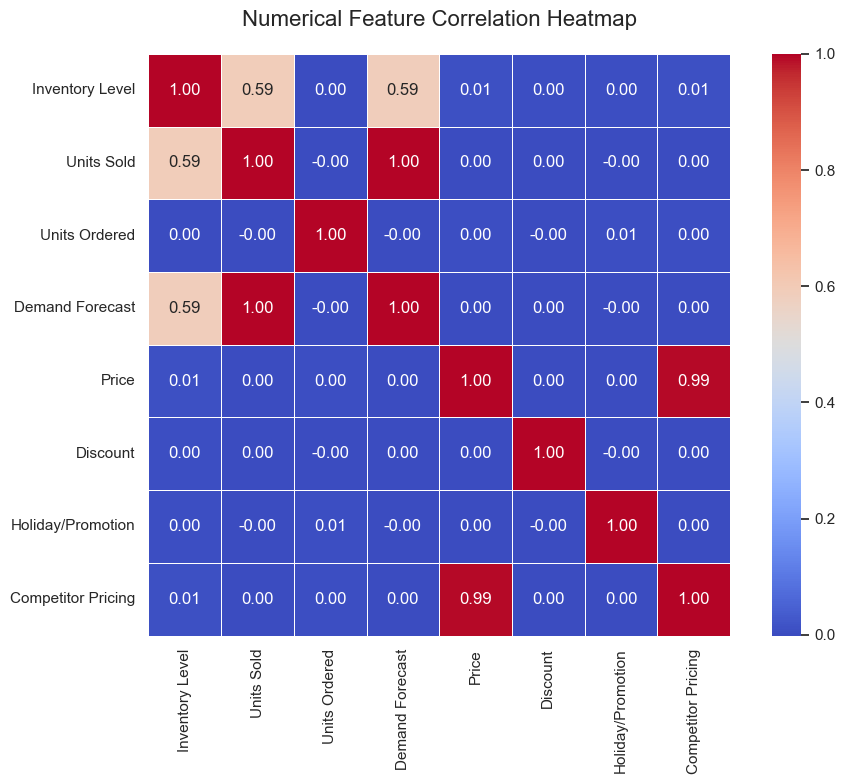

=== Linear Correlation with target variable (Units Sold) ===
Units Sold            1.000000
Demand Forecast       0.996853
Inventory Level       0.589995
Discount              0.002576
Competitor Pricing    0.001259
Price                 0.001082
Holiday/Promotion    -0.000374
Units Ordered        -0.000930
Name: Units Sold, dtype: float64


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Isolate only the numerical columns for calculation
numerical_features = df.select_dtypes(include=[np.number])

# 2. Compute the Pearson correlation matrix
corr_matrix = numerical_features.corr()

# 3. Create the Heatmap Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show numeric values inside squares
    cmap='coolwarm',     # Red for positive correlation, blue for negative
    fmt=".2f",           # Two decimal places
    linewidths=0.5,      # Spacing between squares
    square=True          # Force square boxes
)

plt.title('Numerical Feature Correlation Heatmap', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# 4. Display sorted correlation values specifically for our target
print("=== Linear Correlation with target variable (Units Sold) ===")
print(corr_matrix['Units Sold'].sort_values(ascending=False))

# Feature Engineering


In [4]:
import pandas as pd
import numpy as np

# 1. Load the raw dataset
df = pd.read_csv(r'C:\Users\hp\Desktop\Final_Project\Dataset\retail_store_inventory.csv')

print("--- Starting Feature Engineering & Data Cleaning ---")

# 2. Fix the Negative Demand Forecast Anomaly
# Replacing any negative placeholder values with 0 since physical demand cannot be negative
df['Demand Forecast'] = df['Demand Forecast'].clip(lower=0)

# 3. Time Series & Date Deconstruction
# Converting string dates into rich datetime features
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek  # Monday=0, Sunday=6
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# 4. Interactive Pricing Engineering
# Feature A: Price Advantage (Positive value means our store is cheaper than the competitor)
df['Price_Difference'] = df['Competitor Pricing'] - df['Price']

# Feature B: Effective Price (Realized shelf cost after taking percentage markdown into account)
df['Effective_Price'] = df['Price'] * (1 - df['Discount'] / 100.0)

# 5. Supply Chain & Inventory Optimization Context
# Feature C: Stock-to-Demand Ratio (Helps model evaluate risks of stockout vs overstock)
df['Stock_to_Demand_Ratio'] = df['Inventory Level'] / (df['Demand Forecast'] + 1) # +1 avoids division by zero

# 6. Save the Fully Cleaned and Engineered Dataset
cleaned_file_path = 'cleaned_retail_store_inventory.csv'
df.to_csv(cleaned_file_path, index=False)

print("\n=== FEATURE ENGINEERING COMPLETE ===")
print(f"New Cleaned Dataset Saved As: '{cleaned_file_path}'")
print(f"Original Structure: 15 columns -> Cleaned Structure: {df.shape[1]} columns")
print(f"Final Data Shape: {df.shape}")
print(f"Verified Minimum Demand Forecast: {df['Demand Forecast'].min()}")

--- Starting Feature Engineering & Data Cleaning ---

=== FEATURE ENGINEERING COMPLETE ===
New Cleaned Dataset Saved As: 'cleaned_retail_store_inventory.csv'
Original Structure: 15 columns -> Cleaned Structure: 23 columns
Final Data Shape: (73100, 23)
Verified Minimum Demand Forecast: 0.0


In [5]:
import pandas as pd

# 1. Load the engineered dataset from the previous step
df = pd.read_csv(r'C:\Users\hp\Desktop\Final_Project\Dataset\cleaned_retail_store_inventory.csv')

print(f"Shape before encoding: {df.shape}")

# 2. Identify categorical columns to encode
# We will encode Category, Region, Weather Condition, and Seasonality
columns_to_encode = ['Category', 'Region', 'Weather Condition', 'Seasonality']

# 3. Apply One-Hot Encoding
# drop_first=True helps avoid multi-collinearity (the dummy variable trap) by omitting one baseline column
df_encoded = pd.get_dummies(df, columns=columns_to_encode, drop_first=True, dtype=int)

# 4. Handle high-cardinality IDs (Store ID & Product ID)
# Since there are multiple stores and products, standard label encoding or leaving them as identifiers works best
df_encoded['Store ID'] = df_encoded['Store ID'].astype('category').cat.codes
df_encoded['Product ID'] = df_encoded['Product ID'].astype('category').cat.codes

# 5. Save the finalized numeric dataset
final_numeric_file = 'final_numeric_retail_inventory.csv'
df_encoded.to_csv(final_numeric_file, index=False)

print("\n=== CATEGORICAL ENCODING COMPLETE ===")
print(f"Shape after encoding: {df_encoded.shape}")
print(f"Final fully numeric dataset saved as: '{final_numeric_file}'")
print("\nSample of newly generated columns:")
print([col for col in df_encoded.columns if '_' in col and col not in ['Demand Forecast', 'Price_Difference', 'Effective_Price', 'Stock_to_Demand_Ratio']])

Shape before encoding: (73100, 23)

=== CATEGORICAL ENCODING COMPLETE ===
Shape after encoding: (73100, 32)
Final fully numeric dataset saved as: 'final_numeric_retail_inventory.csv'

Sample of newly generated columns:
['Is_Weekend', 'Category_Electronics', 'Category_Furniture', 'Category_Groceries', 'Category_Toys', 'Region_North', 'Region_South', 'Region_West', 'Weather Condition_Rainy', 'Weather Condition_Snowy', 'Weather Condition_Sunny', 'Seasonality_Spring', 'Seasonality_Summer', 'Seasonality_Winter']
